## 0. Librerías

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os
import re
from pathlib import Path
from typing import Optional


## 1. Ingesta de datos

In [50]:
DROPBOX_URL = "https://www.dropbox.com/scl/fi/udfuu67nwdhz2moxos8n3/df_final.csv?rlkey=krk4w5g930nog0lmehnnm6k15&st=inbi9tma&dl=1"


df = pd.read_csv(
    DROPBOX_URL,
    sep=";",
    engine="python",
    encoding="latin1",
    on_bad_lines="warn"
   )




## 2. Auditoría de datos y configuración

In [51]:
def audit_dataframe(df: pd.DataFrame, audio_col: str = "Identifier") -> dict:
    info = {
        "rows": len(df),
        "cols": df.shape[1],
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        "duplicates_audio": int(df.duplicated(subset=[audio_col]).sum()),
        "unique_audios": df[audio_col].nunique(),
        "nulls_pct": (df.isnull().mean() * 100).round(2).sort_values(ascending=False).to_dict(),
        "dtypes": df.dtypes.astype(str).to_dict(),
    }
    return info

audit = audit_dataframe(df)
audit


{'rows': 279505,
 'cols': 54,
 'memory_mb': np.float64(795.86),
 'duplicates_audio': 256977,
 'unique_audios': 22527,
 'nulls_pct': {'license_y': 100.0,
  'physicalSetting': 100.0,
  'captureDevice': 99.99,
  'caption': 99.99,
  'otherCatalogNumbers': 99.87,
  'identificationRemarks': 99.79,
  'lifeStage': 99.23,
  'sex': 98.99,
  'Associated Taxa': 98.1,
  'infraspecificEpithet': 92.18,
  'Rating': 91.21,
  'behavior': 91.2,
  'resourceCreationTechnique': 91.15,
  'CoreId': 91.14,
  'preparations': 91.14,
  'references': 91.14,
  'rightsHolder_x': 91.14,
  'license_x': 91.14,
  'Identifier': 91.14,
  'rightsHolder_y': 91.14,
  'creator': 91.14,
  'accessURI': 91.14,
  'associatedObservationReference': 91.14,
  'description.1': 91.14,
  'format': 91.14,
  'type': 91.14,
  'variantLiteral': 91.14,
  'dynamicProperties': 73.21,
  'eventTime': 4.96,
  'fieldNotes': 4.22,
  'eventDate': 0.17,
  'verbatimEventDate': 0.05,
  'verbatimElevation': 0.05,
  'recordedBy': 0.05,
  'geodeticDatum':

Hemos confirmado la ausencia de duplicados y formatos de audio únicos. A continuación identificamos los nombres científicos únicos del dataset y el volumen de cada uno

In [52]:
df['scientificName'].unique()

array(['Acrocephalus arundinaceus', 'Acrocephalus dumetorum',
       'Acrocephalus palustris', 'Acrocephalus schoenobaenus',
       'Acrocephalus scirpaceus', 'Actitis hypoleucos',
       'Aegithalos caudatus', 'Aegolius funereus', 'Alauda arvensis',
       'Alauda arvensis arvensis', 'Alcedo atthis', 'Anas crecca',
       'Anas platyrhynchos', 'Anser anser', 'Anthus campestris',
       'Anthus pratensis', 'Anthus spinoletta', 'Anthus trivialis',
       'Apus apus', 'Ardea cinerea', 'Asio otus', 'Athene noctua',
       'Botaurus stellaris', 'Branta leucopsis', 'Bubo bubo',
       'Burhinus oedicnemus', 'Buteo buteo', 'Calidris alpina',
       'Caprimulgus europaeus', 'Carduelis carduelis',
       'Certhia brachydactyla', 'Certhia familiaris', 'Cettia cetti',
       'Charadrius dubius', 'Charadrius hiaticula', 'Chloris chloris',
       'Chroicocephalus ridibundus', 'Cisticola juncidis',
       'Coccothraustes coccothraustes', 'Coloeus monedula',
       'Columba palumbus', 'Corvus corax'

In [53]:
# Volumen de registros por especie
pd.set_option('display.max_rows', None)
df['scientificName'].value_counts()


scientificName
Mystery mystery                        11079
Parus major                             7100
Turdus merula                           6852
Erithacus rubecula                      6100
Fringilla coelebs                       5767
Phylloscopus collybita                  4980
Sylvia atricapilla                      4884
Turdus philomelos                       4704
Troglodytes troglodytes                 4336
Cyanistes caeruleus                     3678
Emberiza calandra                       3141
Strix aluco                             3094
Turdus iliacus                          3086
Phylloscopus trochilus                  3029
Emberiza citrinella                     2832
Rallus aquaticus                        2722
Corvus cornix cornix                    2711
Curruca communis                        2705
Dendrocopos major                       2672
Loxia curvirostra                       2659
Luscinia megarhynchos                   2544
Fulica atra                             

In [54]:
df['scientificName'].nunique()
#Son 180 especies

180

In [55]:
# Configuraciones y constantes
MIN_SAMPLES_PER_SPECIES = 200
CAP_SAMPLES_PER_SPECIES = 800
RANDOM_SEED = 42

CANDIDATE_LABEL_COLS = ["scientificName", "species", "label"]
CANDIDATE_AUDIO_COLS = ["OcurrenceID", "audio_url", "soundUrl", "accessURI","identifier", "url", "audio", "media_url"]
CANDIDATE_COUNTRY_COLS = ["country", "countryCode", "country_code"]
META_COLS = ["vernacularName", "family", "behavior", "description"]  
label_key = "scientificName"

INVALID_LABEL_PATTERNS = [
    r"^\s*$",
    r"^mystery\s*$",
    r"^unknown\s*$",
    r"^unidentified\s*$",
    r"^sp\.\s*$",
]

# Ampliamos el conjunto de extensiones de audio permitidas
ALLOWED_AUDIO_EXT = {"mp3", "wav", "flac", "ogg", "wma", "m4a"}

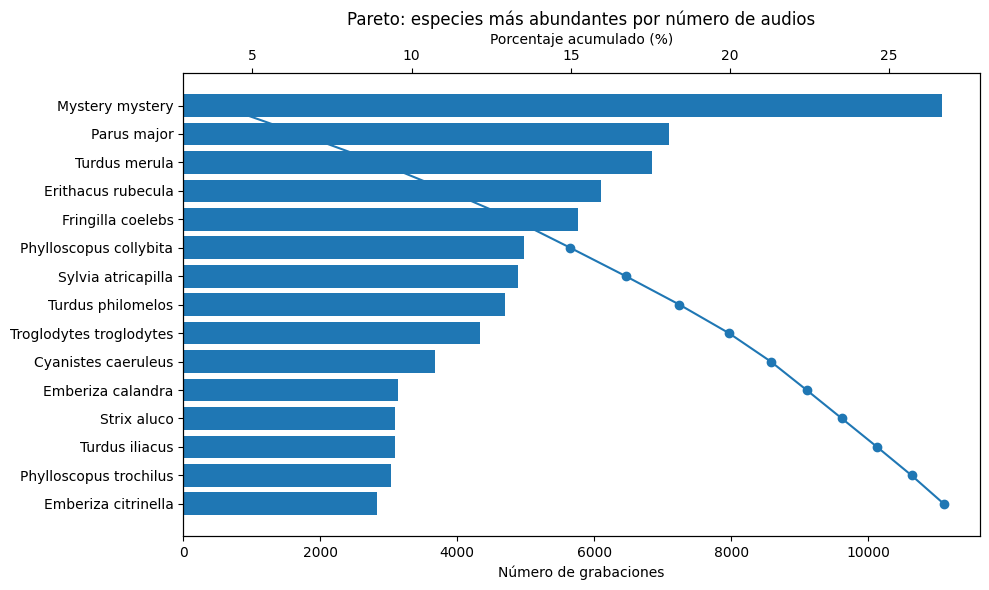

In [56]:
top_n = 15

df_pareto = (
    df.groupby("scientificName")
      .size()
      .reset_index(name="n_audios")
      .sort_values("n_audios", ascending=False)
)

# Porcentaje acumulado
df_pareto["cum_pct"] = df_pareto["n_audios"].cumsum() / df_pareto["n_audios"].sum() * 100


df_top = df_pareto.head(top_n)

# Gráfico de Pareto
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.barh(
    df_top["scientificName"][::-1],
    df_top["n_audios"][::-1]
)
ax1.set_xlabel("Número de grabaciones")
ax1.set_title("Pareto: especies más abundantes por número de audios")

ax2 = ax1.twiny()
ax2.plot(
    df_top["cum_pct"][::-1],
    df_top["scientificName"][::-1],
    marker="o"
)
ax2.set_xlabel("Porcentaje acumulado (%)")

plt.tight_layout()
plt.show()




El análisis de Pareto muestra una distribución altamente asimétrica del número de grabaciones por especie, con una concentración significativa en un subconjunto reducido de clases. Este desbalance justifica la aplicación de técnicas de balanceo previo al entrenamiento para evitar sesgos del modelo hacia las especies mayoritarias. Hay una concentración muy fuerte de audios en pocas especies. Las primeras 5–6 especies ya explican una parte relevante del volumen total, mientras que el resto entra claramente en cola larga. La categoría "Mystery mystery" ha de ser excluida del dataset final ya que es una alerta de la calidad del dataset. Pueden ser audios mal etiquetados o bien mal filtrados, pero afectarían al entrenamiento negativamente

### 3. Helpers

In [57]:
# Devuelve el nombre de la primera columna existente en el DataFrame de la lista de candidatos (si no, lanza error)
def pick_col(df: pd.DataFrame, candidates: list[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"No se encontró ninguna de estas columnas: {candidates}")

# Normaliza el texto: convierte a str, quita espacios extras
def normalize_text(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Verifica si una etiqueta es inválida
def is_invalid_label(x: str) -> bool:
    xl = (x or "").strip().lower()
    return any(re.match(p, xl) for p in INVALID_LABEL_PATTERNS)

# Extrae la extensión de audio de la URL
def infer_audio_ext(url: str) -> str:
    if not isinstance(url, str):
        return ""
    m = re.search(r"\.([a-z0-9]{2,5})(?:\?|#|$)", url.lower())
    return m.group(1) if m else ""


### 5. Selección de columnas clave (label, audio y country)

In [58]:
CANDIDATE_AUDIO_COLS = [
    "fileName",
    "file",
    "OcurrenceID",
    "accessURI"
    "media",
    "identifier",
    "references",
    "associatedMedia",
    "audio",
    "url"
]

audio_col = pick_col(df, CANDIDATE_AUDIO_COLS)
print("Audio col:", audio_col)

Audio col: references


In [59]:
label_col = pick_col(df, CANDIDATE_LABEL_COLS)
audio_col = pick_col(df, CANDIDATE_AUDIO_COLS)
meta_col = pick_col(df, META_COLS)

country_col: Optional[str] = None
for c in CANDIDATE_COUNTRY_COLS:
    if c in df.columns:
        country_col = c
        break

print("Label col:", label_col)
print("Audio col:", audio_col)
print("Country col:", country_col)
print("Meta col:", meta_col)

keep_cols = [label_col, audio_col, meta_col] + ([country_col] if country_col else [])
df0 = df[keep_cols].copy()

df0.head()


Label col: scientificName
Audio col: references
Country col: country
Meta col: vernacularName


,scientificName,references,vernacularName,country
0,Acrocephalus arundinaceus,NaN,Great Reed Warbler,Sweden
1,Acrocephalus arundinaceus,NaN,Great Reed Warbler,Sweden
2,Acrocephalus arundinaceus,NaN,Great Reed Warbler,Greece
3,Acrocephalus arundinaceus,NaN,Great Reed Warbler,Netherlands
4,Acrocephalus arundinaceus,NaN,Great Reed Warbler,Belgium


### 7. Limpieza de archivos de audio

In [60]:
df1 = df0.copy()

df1[label_col] = normalize_text(df1[label_col])
df1[audio_col] = df1[audio_col].astype(str).str.strip()

before = len(df1)

# Remove missing
df1 = df1[df1[label_col].notna() & (df1[label_col] != "")]
df1 = df1[df1[audio_col].notna() & (df1[audio_col] != "")]

# Remove invalid labels (Mystery/Unknown/etc.)
df1 = df1[~df1[label_col].apply(is_invalid_label)]

# Deduplicate by (species + audio)
df1 = df1.drop_duplicates(subset=[label_col, audio_col])

print(f"Tras limpieza: {len(df1):,} (−{before - len(df1):,})")
df1.head(3)


Tras limpieza: 22,723 (−256,782)


,scientificName,references,vernacularName,country
0,Acrocephalus arundinaceus,nan,Great Reed Warbler,Sweden
5,Acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Spain
20,Acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Poland


### 8. Refuerzo del formato de audio

In [61]:
df2 = df1.copy()

df2["audio_ext"] = df2[audio_col].apply(infer_audio_ext)

before = len(df2)
df2 = df2[df2["audio_ext"].isin(ALLOWED_AUDIO_EXT) | (df2["audio_ext"] == "")]
print(f"Tras filtro formato: {len(df2):,} (−{before - len(df2):,})")

df2["audio_ext"].value_counts().head(10)

Tras filtro formato: 22,723 (−0)


audio_ext
    22723
Name: count, dtype: int64

### 9. Filtro de especies for mínimo de muestras

In [62]:
df3 = df2.copy()

counts = df3[label_col].value_counts()
keep_species = counts[counts >= MIN_SAMPLES_PER_SPECIES].index

before = len(df3)
df3 = df3[df3[label_col].isin(keep_species)].copy()

print(f"Especies retenidas: {df3[label_col].nunique():,}")
print(f"Filas tras min_samples: {len(df3):,} (−{before - len(df3):,})")

df3[label_col].value_counts().head(10)

Especies retenidas: 24
Filas tras min_samples: 7,943 (−14,780)


scientificName
Mystery mystery           1508
Erithacus rubecula         413
Turdus merula              382
Sylvia atricapilla         357
Parus major                351
Fringilla coelebs          344
Turdus philomelos          335
Rallus aquaticus           332
Acrocephalus palustris     297
Phylloscopus collybita     292
Name: count, dtype: int64

### 10. Balanceo por clase (cap por especie)

In [63]:
df_balanced = (
    df3.groupby(label_col, group_keys=False)
       .apply(lambda g: g.sample(n=min(len(g), CAP_SAMPLES_PER_SPECIES), random_state=RANDOM_SEED))
       .reset_index(drop=True)
)

print("Especies finales:", df_balanced[label_col].nunique())
print("Audios totales:", len(df_balanced))
df_balanced[label_col].value_counts().describe()


Especies finales: 24
Audios totales: 7235


C:\Users\anto-\AppData\Local\Temp\ipykernel_21440\2085845784.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), CAP_SAMPLES_PER_SPECIES), random_state=RANDOM_SEED))


count     24.000000
mean     301.458333
std      121.934401
min      205.000000
25%      234.500000
50%      268.000000
75%      337.250000
max      800.000000
Name: count, dtype: float64

### 11. Sanity check

In [68]:
# Identificar etiquetas inválidas
bad_mask = (
    df_balanced[label_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.contains(r"\b(mystery|unknown|unidentified)\b")
)

bad = df_balanced[bad_mask]
print("Bad labels rows (to be removed):", len(bad))

# Eliminación explícita de etiquetas inválidas
df_balanced = df_balanced[~bad_mask].copy()

print("Rows after removing bad labels:", len(df_balanced))

# Distribución por país
if country_col and country_col in df_balanced.columns:
    print("\nDistribución por país (Top 20):")
    display(
        df_balanced[country_col]
        .value_counts(dropna=False)
        .head(20)
    )

# Distribución y balance por especie (audios por especie)
if label_col and label_col in df_balanced.columns:
    vc = df_balanced[label_col].value_counts(dropna=False)

    print("\nDistribución de audios por especie (Top 20):")
    display(vc.head(20))

    print("\nBalance por especie:")
    print("Especies totales:", vc.shape[0])
    print("Min samples per species:", vc.min())
    print("Max samples per species:", vc.max())
    print("Media samples per species:", round(vc.mean(), 2))
    print("Mediana samples per species:", vc.median())
else:
    print("label_col no está definido o no existe en df_balanced.")


Bad labels rows (to be removed): 800
Rows after removing bad labels: 6435

Distribución por país (Top 20):


C:\Users\anto-\AppData\Local\Temp\ipykernel_21440\4243290677.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(r"\b(mystery|unknown|unidentified)\b")


country
France            1380
Netherlands       1043
Belgium            770
Sweden             644
United Kingdom     475
Spain              435
Germany            398
Switzerland        218
Poland             200
Italy              192
Austria            106
Denmark             90
Portugal            87
Norway              76
Ukraine             75
Finland             55
Ireland             34
Hungary             24
Czech Republic      23
Turkey              20
Name: count, dtype: int64


Distribución de audios por especie (Top 20):


scientificName
Erithacus rubecula         413
Turdus merula              382
Sylvia atricapilla         357
Parus major                351
Fringilla coelebs          344
Turdus philomelos          335
Rallus aquaticus           332
Acrocephalus palustris     297
Phylloscopus collybita     292
Actitis hypoleucos         291
Troglodytes troglodytes    280
Luscinia megarhynchos      256
Emberiza hortulana         252
Gallinula chloropus        244
Strix aluco                240
Tachybaptus ruficollis     235
Fulica atra                235
Anthus trivialis           233
Turdus iliacus             229
Dendrocopos major          212
Name: count, dtype: int64


Balance por especie:
Especies totales: 23
Min samples per species: 205
Max samples per species: 413
Media samples per species: 279.78
Mediana samples per species: 256.0


In [65]:
# Dimensiones finales
n_rows, n_cols = df_balanced.shape

print("Dimensiones finales del dataset")
print(f"- Filas (audios): {n_rows:,}")
print(f"- Columnas: {n_cols}")

# Número de clases (especies)
n_species = df_balanced[label_col].nunique()
print(f"- Nº de especies (clases): {n_species}")

# Muestras por clase (resumen)
vc = df_balanced[label_col].value_counts()
print("\n Muestras por especie")
print(f"- Mínimo: {vc.min()}")
print(f"- Máximo: {vc.max()}")
print(f"- Media: {vc.mean():.1f}")
print(f"- Mediana: {vc.median()}")

Dimensiones finales del dataset
- Filas (audios): 7,235
- Columnas: 5
- Nº de especies (clases): 24

 Muestras por especie
- Mínimo: 205
- Máximo: 800
- Media: 301.5
- Mediana: 268.0


In [66]:
# Verificar nulos
print("\n Nulos por columna")
print(df_balanced.isna().sum())

# Verificar duplicados
print("\n Filas duplicadas:", df_balanced.duplicated().sum())

# Top 10 especies por volumen
print("\n Top 10 especies por volumen")
display(df_balanced[label_col].value_counts().head(10))



 Nulos por columna
scientificName    0
references        0
vernacularName    0
country           0
audio_ext         0
dtype: int64

 Filas duplicadas: 0

 Top 10 especies por volumen


scientificName
Mystery mystery           800
Erithacus rubecula        413
Turdus merula             382
Sylvia atricapilla        357
Parus major               351
Fringilla coelebs         344
Turdus philomelos         335
Rallus aquaticus          332
Acrocephalus palustris    297
Phylloscopus collybita    292
Name: count, dtype: int64

## 12. Outputs - guardar el dataframe final procesado

In [67]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

for p in [DATA_RAW, DATA_PROCESSED, REPORTS]:
    p.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('c:/Users/anto-/Downloads')